# Notebook principal — INF6243

Ce notebook exécute la même orchestration multi-runs que la CLI (`main.py` racine), mais en mode interactif.

Objectifs de ce notebook:
- configurer rapidement les runs à comparer;
- lancer l'entraînement/évaluation depuis une seule interface;
- interpréter les résultats (tableaux, diagnostics, figures) sans naviguer dans tout le code;
- comprendre quel run et quel modèle sont retenus, et pourquoi.

Flux conseillé:
1. Exécuter les imports.
2. Modifier les paramètres utilisateur.
3. Lancer `run_all_configs`.
4. Lire la synthèse (`report`) et les tableaux.
5. Ouvrir les artefacts dans `Outputs/`.

In [1]:
from pathlib import Path
import os
import subprocess
import pandas as pd
from time import perf_counter
from IPython.display import display, Markdown, Image

import sys

sys.path.insert(0, "Code")
from notebook_workflow import (
    build_models_table,
    build_runs_comparison_table,
    load_report,
    run_all_configs,
)
from result_interpreter import interpret_report
import run_configs

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
URL = "/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv"

if not os.path.exists(URL):
    URL = Path("data/labeled_data.csv")
    print("target =", URL.resolve())
    print("exists =", URL.exists())
    if not URL.exists():
        URL.parent.mkdir(parents=True, exist_ok=True)
        print("exists =", URL.parent.exists())
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/hate-speech-and-offensive-language-dataset.zip \
            https://www.kaggle.com/api/v1/datasets/download/mrmorj/hate-speech-and-offensive-language-dataset"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/hate-speech-and-offensive-language-dataset.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
df = pd.read_csv(URL)

print(f"Shape: {df.shape}")
df.head()

target = /workspace/data/labeled_data.csv
exists = False
exists = True

total 1032
drwxrwxrwx 1 root   root        92 Apr 21 03:36 .
drwxrwxrwx 1 root   root       596 Apr 15 14:40 ..
-rw-r--r-- 1 ubuntu ubuntu 1055041 Apr 21 03:36 hate-speech-and-offensive-language-dataset.zip

Archive:  data/hate-speech-and-offensive-language-dataset.zip
  inflating: data/labeled_data.csv   

total 3520
drwxrwxrwx 1 root   root       124 Apr 21 03:36 .
drwxrwxrwx 1 root   root       596 Apr 15 14:40 ..
-rw-r--r-- 1 ubuntu ubuntu 1055041 Apr 21 03:36 hate-speech-and-offensive-language-dataset.zip
-rw-r--r-- 1 ubuntu ubuntu 2546446 Jun 17  2020 labeled_data.csv

Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Paramètres du notebook (à modifier)

Cette section regroupe tous les paramètres utilisateur. Les profils détaillés et les grilles restent centralisés dans `Code/run_configs.py` (source unique notebook + CLI).

### Paramètres de pilotage

- `RUN_MATRIX`
  - `"default"`: moins de runs, plus rapide pour itérer.
  - `"exhaustive"`: couverture plus large, coût plus élevé.

- `SELECTED_MODELS`
  - Sous-ensemble de modèles à garder dans la matrice.
  - Utiliser les noms de `run_configs.BASE_MODEL_NAMES`.
  - Exemple: `("DistilBERT", "LinearSVC", "KNNGPU")`.
  - Les runs sont filtrés automatiquement selon cette liste.

- `DISTILBERT_PROXY_PENALTY`
  - Malus appliqué lors de la comparaison inter-runs quand DistilBERT utilise un score CV proxy.
  - Recommandé: `0.00` à `0.05`.
  - Plus la valeur est grande, plus la sélection finale est prudente envers ce type de run.

### Paramètres GPU / DistilBERT / grilles

- `GPU_MODELS_ENABLED`
  - Active/désactive les modèles cuML (`LogisticRegressionGPU`, `LinearSVCGPU`, `KNNGPU`, `RandomForestGPU`).

- `GPU_PROFILES_ENABLED`
  - Profils de tuning GPU: `gpu_fast`, `gpu_balanced`, `gpu_aggressive`.

- `DISTILBERT_PROFILES_ENABLED`
  - Profils DistilBERT: `fast`, `balanced`, `robust`, `vram_max`.
  - Variables les plus impactantes: `epochs`, `batch_size`, `max_length`.

- `MLP_PROFILES_ENABLED` / `ADABOOST_PROFILES_ENABLED`
  - Profils de tuning classiques.
  - Plus un profil est large, plus le temps de GridSearchCV augmente.

### Comment choisir rapidement

- Prototype rapide: `RUN_MATRIX="default"` + peu de modèles.
- Analyse finale: `RUN_MATRIX="exhaustive"` + profils ciblés.
- Machine limitée en RAM/VRAM: éviter `gpu_aggressive` et `vram_max`.
- Environnement incomplet (pas de cuML / pas de torch-transformers): les runs incompatibles sont ignorés sans casser le notebook.

In [6]:
# Paramètres utilisateur uniquement (la logique est centralisée dans `Code/run_configs.py`).

# Choix de la matrice de runs:
# - "default": exécution rapide
# - "exhaustive": couverture complète des profils
RUN_MATRIX = "default"  # "default" ou "exhaustive"

# Sélection directe des modèles à lancer depuis le notebook.
#
# Modèles disponibles (noms exacts à utiliser):
# - NaiveBayes
# - LogisticRegression
# - LinearSVC
# - KNN
# - DecisionTree
# - RandomForest
# - AdaBoost
# - MLPClassifier
# - LogisticRegressionGPU
# - LinearSVCGPU
# - KNNGPU
# - RandomForestGPU
# - DistilBERT
#
# Comment sélectionner / ne pas sélectionner:
# - Tous les modèles: SELECTED_MODELS = tuple(AVAILABLE_MODELS)
# - Inclure seulement certains modèles: SELECTED_MODELS = ("LinearSVC", "KNN", "DistilBERT")
# - Exclure certains modèles: SELECTED_MODELS = tuple(m for m in AVAILABLE_MODELS if m not in ("DistilBERT", "KNNGPU"))
# - Aucun modèle (déconseillé): une erreur explicite est levée.
#
# Important: les noms sont sensibles à la casse et doivent correspondre exactement.
AVAILABLE_MODELS = tuple(run_configs.BASE_MODEL_NAMES)
# Exemples:
SELECTED_MODELS = tuple(AVAILABLE_MODELS)
# SELECTED_MODELS = ("LinearSVC", "KNN", "MLPClassifier")
# SELECTED_MODELS = ("LinearSVCGPU", "KNNGPU", "RandomForestGPU", "LogisticRegressionGPU")
# SELECTED_MODELS = ("DistilBERT","LogisticRegression", "RandomForest")
SELECTED_MODELS = ("DistilBERT", "MLPClassifier",)


# Malus de prudence pour les runs DistilBERT évalués avec CV proxy.
# Recommandé: 0.00 à 0.05.
# DISTILBERT_PROXY_PENALTY = run_configs.DISTILBERT_PROXY_PENALTY_DEFAULT
DISTILBERT_PROXY_PENALTY = 0.00

# Options disponibles (profils/modèles exposés par run_configs).
RUN_OPTIONS = run_configs.get_available_exhaustive_options()

# Modèles GPU activés (retirer un nom pour désactiver).
GPU_MODELS_ENABLED = (RUN_OPTIONS["gpu_models"])

# Profils GPU activés: fast (rapide), balanced (compromis), aggressive (plus coûteux).
GPU_PROFILES_ENABLED = ("gpu_fast", "gpu_balanced", "gpu_aggressive")
# GPU_PROFILES_ENABLED = ("gpu_aggressive",)

# Profils activés par famille de modèles.
DISTILBERT_PROFILES_ENABLED = tuple(RUN_OPTIONS["distilbert_profiles"])
MLP_PROFILES_ENABLED = tuple(RUN_OPTIONS["mlp_profiles"])
ADABOOST_PROFILES_ENABLED = tuple(RUN_OPTIONS["adaboost_profiles"])
# DISTILBERT_PROFILES_ENABLED = ("balanced", "robust")
# MLP_PROFILES_ENABLED = ("ultra",)
# ADABOOST_PROFILES_ENABLED = ("ultra",)

selected_set = set(SELECTED_MODELS)
unknown_models = sorted(selected_set.difference(AVAILABLE_MODELS))
if unknown_models:
    raise ValueError(
        "Modèles inconnus dans SELECTED_MODELS: "
        f"{unknown_models}. Disponibles: {AVAILABLE_MODELS}"
    )

# Construction des runs à exécuter + filtrage automatique des runs incompatibles
# (dépendances manquantes pour DistilBERT ou cuML).
RUNS, SKIPPED_RUNS = run_configs.build_active_runs(
    run_matrix=RUN_MATRIX,
    include_baseline=True,
    distilbert_profile_names=DISTILBERT_PROFILES_ENABLED,
    mlp_profile_names=MLP_PROFILES_ENABLED,
    adaboost_profile_names=ADABOOST_PROFILES_ENABLED,
    gpu_profile_names=GPU_PROFILES_ENABLED,
    gpu_model_names=GPU_MODELS_ENABLED,
)
if SKIPPED_RUNS:
    print("Runs ignorés (dépendances absentes):", ", ".join(SKIPPED_RUNS))

# Filtrage final des runs selon SELECTED_MODELS.
FILTERED_RUNS = {}
for run_name, run_ctx in RUNS.items():
    run_cfg = dict(run_ctx["config"])
    run_switches = run_cfg.get("algorithm_switches", {})
    if not isinstance(run_switches, dict):
        continue

    filtered_switches = {
        model_name: bool(enabled) and (model_name in selected_set)
        for model_name, enabled in run_switches.items()
    }
    if not any(filtered_switches.values()):
        continue

    run_cfg["algorithm_switches"] = filtered_switches
    run_cfg["include_distilbert"] = bool(filtered_switches.get("DistilBERT", False))
    FILTERED_RUNS[run_name] = {
        "why": run_ctx["why"] + " [filtré via SELECTED_MODELS]",
        "config": run_cfg,
    }

RUNS = FILTERED_RUNS
if not RUNS:
    raise ValueError(
        "Aucun run actif après filtrage par SELECTED_MODELS. "
        "Ajustez la sélection de modèles ou les profils activés."
    )

print("Profils actifs:")
print("- DistilBERT:", DISTILBERT_PROFILES_ENABLED)
print("- MLP:", MLP_PROFILES_ENABLED)
print("- AdaBoost:", ADABOOST_PROFILES_ENABLED)
print("- GPU models:", GPU_MODELS_ENABLED)
print("- GPU profiles:", GPU_PROFILES_ENABLED)
print("- Models sélectionnés:", SELECTED_MODELS)
print("- Runs actifs:", tuple(RUNS.keys()))

# Exécute la matrice de runs et mesure le temps total notebook.
t0 = perf_counter()
workflow = run_all_configs(RUNS, distilbert_proxy_penalty=DISTILBERT_PROXY_PENALTY)
print(f"[timing] notebook_run_all_configs: {perf_counter() - t0:.2f}s")
run_summary_df = workflow["run_summary_df"]
BEST_RUN = workflow["best_run"]
artifacts = workflow["artifacts"]
FIGURE_NAMES = workflow["figure_names"]

# Affichage synthétique des scores inter-runs.
display(
    run_summary_df[
        [
            "run",
            "best_model",
            "include_distilbert",
            "distilbert_cv_proxy",
            "fairness_penalty",
            "best_selection_score",
            "adjusted_selection_score",
            "best_test_f1_macro",
        ]
    ]
)
print(f"Run de reference selectionne (score ajusté): {BEST_RUN}")
artifacts

Profils actifs:
- DistilBERT: ('fast', 'balanced', 'robust', 'vram_max')
- MLP: ('fast', 'balanced', 'wide', 'ultra')
- AdaBoost: ('fast', 'balanced', 'wide', 'ultra')
- GPU models: ['KNNGPU', 'LinearSVCGPU', 'LogisticRegressionGPU', 'RandomForestGPU']
- GPU profiles: ('gpu_fast', 'gpu_balanced', 'gpu_aggressive')
- Models sélectionnés: ('DistilBERT', 'MLPClassifier')
- Runs actifs: ('run_g_distilbert_safe_ep2',)
Execution: run_g_distilbert_safe_ep2
Pourquoi: Run DistilBERT ep2 avec pondération adaptée au CV proxy. [filtré via SELECTED_MODELS]
Configuration: {'max_samples': None, 'distilbert_epochs': 2, 'include_distilbert': True, 'test_size': 0.2, 'val_size': 0.1, 'cv_folds': 5, 'scoring': 'f1_macro', 'model_param_overrides': {'DistilBERT': {'epochs': 2, 'batch_size': 16, 'max_length': 160, 'learning_rate': 3e-05, 'weight_decay': 0.01}}, 'model_grid_overrides': {}, 'selection_weights': (0.3, 0.35, 0.2, 0.15), 'algorithm_switches': {'NaiveBayes': False, 'LogisticRegression': False, 'Li

,run,best_model,include_distilbert,distilbert_cv_proxy,fairness_penalty,best_selection_score,adjusted_selection_score,best_test_f1_macro
0,run_g_distilbert_safe_ep2,MLPClassifier,True,False,0.0,0.493662,0.493662,0.60237


Run de reference selectionne (score ajusté): run_g_distilbert_safe_ep2


{'best_model_name': 'MLPClassifier',
 'best_model_path': '/workspace/Outputs/models/best_model.joblib',
 'report_path': '/workspace/Outputs/reports/metrics_report.json',
 'figures_dir': '/workspace/Outputs/figures',
 'outputs_dir': '/workspace/Outputs'}

## Pourquoi une matrice explicite de runs ?

- Objectif: comparer des familles de modèles et de profils sans perdre la traçabilité.
- Couverture: 1 run = 1 combinaison métier lisible (baseline, profils DistilBERT, profils MLP/AdaBoost, profils GPU).
- Coût maîtrisé: on évite un produit cartésien géant de toutes les grilles.
- Comparaison équitable: même formule de sélection partout, avec compensation DistilBERT CV proxy (`DISTILBERT_PROXY_PENALTY`).
- Maintenance: la matrice est définie une seule fois dans `Code/run_configs.py`, réutilisée en notebook et en CLI.

En pratique, cette approche donne:
1. une lecture claire des gains/pertes par profil;
2. une meilleure reproductibilité des essais;
3. un chemin simple pour raffiner ensuite uniquement les runs prometteurs.

In [7]:
t0 = perf_counter()
report = load_report(Path(artifacts["report_path"]))
print(f"[timing] notebook_load_report: {perf_counter() - t0:.2f}s")

print("Meilleur modèle:", report.get("best_model"))
print("Métriques test:", report.get("best_model_test_metrics"))
print("DistilBERT:", report.get("distilbert_note"))
print("Configuration:", report.get("run_config"))
display(Markdown("**Justification:** " + report.get("best_model_selection_explanation", "")))

phase_times = report.get("timing_seconds", {})
if phase_times:
    print("\nTemps d'exécution par phase (pipeline):")
    for phase_name, seconds in sorted(phase_times.items(), key=lambda item: item[1], reverse=True):
        print(f"- {phase_name}: {seconds:.2f}s")

[timing] notebook_load_report: 0.00s
Meilleur modèle: MLPClassifier
Métriques test: {'accuracy': 0.8616098446641114, 'balanced_accuracy': 0.6043767962878493, 'precision_macro': 0.7205225117453334, 'recall_macro': 0.6043767962878493, 'f1_macro': 0.6023701797882745}
DistilBERT: DistilBERT inclus dans la comparaison.
Configuration: {'max_samples': None, 'distilbert_epochs': 2, 'include_distilbert': True, 'algorithm_switches': {'NaiveBayes': False, 'LogisticRegression': False, 'LinearSVC': False, 'KNN': False, 'DecisionTree': False, 'RandomForest': False, 'AdaBoost': False, 'MLPClassifier': True, 'LogisticRegressionGPU': False, 'LinearSVCGPU': False, 'KNNGPU': False, 'RandomForestGPU': False, 'DistilBERT': True}, 'test_size': 0.2, 'val_size': 0.1, 'cv_folds': 5, 'scoring': 'f1_macro', 'model_param_overrides': {'DistilBERT': {'epochs': 2, 'batch_size': 16, 'max_length': 160, 'learning_rate': 3e-05, 'weight_decay': 0.01}}, 'model_grid_overrides': {}, 'selection_weights': [0.3, 0.35, 0.2, 0.1

**Justification:** Le modèle MLPClassifier obtient le meilleur score global pondéré (0.4937) en combinant validation, test, CV et rappel `hate_speech` (avec pénalité éventuelle sous seuil). Il est retenu pour son compromis entre performance et robustesse.


Temps d'exécution par phase (pipeline):
- pipeline_total: 178.39s
- cv_and_selection_scores: 125.56s
- train_models: 42.14s
- evaluate_on_test: 5.03s
- best_model_figures: 4.19s
- load_clean_sample_data: 0.61s
- eda_summary_and_figures: 0.55s
- evaluation_figures: 0.15s
- save_artifacts_and_error_analysis: 0.08s
- prepare_outputs_and_device: 0.02s
- split_train_val_test: 0.01s
- save_final_report: 0.00s


In [8]:
# Tableau complet: tous les modèles, statut, métriques, hyperparamètres
build_models_table(report)

,model,status,error_or_reason,selection_score,balanced_accuracy,val_f1_macro,test_f1_macro,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_macro_ci95,hate_recall_test,hate_f1_test,offensive_f1_test,neither_f1_test,penalty_applied,representation,best_cv_score,best_params
0,MLPClassifier,trained,None,0.493662,0.604377,0.601827,0.602370,0.59586,0.018475,0.016194,0.087413,0.151515,0.920924,0.734671,0.03,TF-IDF sparse vectors,0.595784,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
1,DistilBERT,trained,None,NaN,0.749520,0.760656,0.761844,NaN,NaN,NaN,0.402098,0.447471,0.948907,0.889155,0.00,Transformer embeddings,NaN,"{'model_name': 'distilbert-base-uncased', 'epo..."


In [9]:
# Interpreteur de resultats (script dedie)
interpreter_summary = interpret_report(report, weak_f1_threshold=0.55)
interpreter_summary

=== INTERPRETATION RAPIDE ===
Meilleur modele: MLPClassifier
Score de selection: 0.4937
Politique scoring: selection_score = w_val * val_f1_macro + w_test * test_f1_macro + w_cv * cv_f1_macro_mean + w_hate * hate_recall_test - penalty_if(hate_recall_test < hate_recall_floor)
Precision (diagnostic): La précision macro est suivie comme métrique diagnostique, mais n'est pas utilisée comme critère principal de sélection.

Statuts des modeles:
trained: 2

Top 3 modeles (score global): ['MLPClassifier', 'DistilBERT']

Diagnostic par modele entraine:
- MLPClassifier: selection=0.4937 | val_f1=0.6018 | test_f1=0.6024 | balanced_acc=0.6044 | cv_mean=0.5959 ± 0.0162 | hate_f1=0.1515 | hate_recall=0.0874 | penalty=0.0300 | generalisation stable | stabilite forte | CV stable
- DistilBERT: selection=nan | val_f1=0.7607 | test_f1=0.7618 | balanced_acc=0.7495 | cv_mean=nan ± nan | hate_f1=0.4475 | hate_recall=0.4021 | penalty=0.0000 | generalisation stable | stabilite faible | CV instable

Recommanda

{'status_counts': {'trained': 2},
 'top_models': ['MLPClassifier', 'DistilBERT'],
 'weak_models': []}

## Lecture des résultats: cas DistilBERT et artefacts

### Pourquoi `best_cv_score` peut être vide pour DistilBERT ?

- Les modèles classiques passent par `GridSearchCV`, donc ils exposent un `best_cv_score`.
- DistilBERT est entraîné en fine-tuning direct pour éviter un coût de CV complet trop élevé.
- Le fallback de robustesse est tracé dans `model_selection_method.cv_fallback_for_models`.

### Où lire les sorties utiles après exécution ?

- Rapport principal: `Outputs/reports/metrics_report.json`.
- Version lisible: `Outputs/reports/metrics_report.md`.
- Comparaison inter-runs: `Outputs/reports/runs_comparison_overview.md`.
- Figures: `Outputs/figures/`.

### Vérifications recommandées avant conclusion

- comparer `adjusted_selection_score` (et pas uniquement le score brut);
- vérifier `hate_recall_test` et `hate_f1_test` sur les meilleurs candidats;
- relire les statuts (`trained`, `skipped`, `failed`) pour éviter une conclusion biaisée.

In [10]:
# Comparaison inter-runs (avec compensation DistilBERT CV proxy)
reports_dir = Path(artifacts["report_path"]).parent
comparison_df = build_runs_comparison_table(
    reports_dir,
    distilbert_proxy_penalty=DISTILBERT_PROXY_PENALTY,
)

if comparison_df.empty:
    print("Aucun report multi-run detecte.")
else:
    ordered_cols = [
        "run",
        "best_model",
        "include_distilbert",
        "distilbert_cv_proxy",
        "fairness_penalty",
        "best_selection_score",
        "adjusted_selection_score",
        "best_test_f1_macro",
        "distilbert_note",
    ]
    display(comparison_df[ordered_cols])

    print("\n=== Ligue classique (sans DistilBERT) ===")
    classic_df = comparison_df[comparison_df["include_distilbert"] == False]
    if classic_df.empty:
        print("Aucun run classique trouvé.")
    else:
        display(classic_df[ordered_cols])

    print("\n=== Ligue étendue (avec DistilBERT) ===")
    distil_df = comparison_df[comparison_df["include_distilbert"] == True]
    if distil_df.empty:
        print("Aucun run DistilBERT trouvé.")
    else:
        display(distil_df[ordered_cols])

    print("Astuce: la comparaison est aussi disponible en figure (runs_comparison_overview.png).")

,run,best_model,include_distilbert,distilbert_cv_proxy,fairness_penalty,best_selection_score,adjusted_selection_score,best_test_f1_macro,distilbert_note
0,run_g_distilbert_safe_ep2,MLPClassifier,True,False,0.0,0.493662,0.493662,0.60237,DistilBERT inclus dans la comparaison.



=== Ligue classique (sans DistilBERT) ===
Aucun run classique trouvé.

=== Ligue étendue (avec DistilBERT) ===


,run,best_model,include_distilbert,distilbert_cv_proxy,fairness_penalty,best_selection_score,adjusted_selection_score,best_test_f1_macro,distilbert_note
0,run_g_distilbert_safe_ep2,MLPClassifier,True,False,0.0,0.493662,0.493662,0.60237,DistilBERT inclus dans la comparaison.


Astuce: la comparaison est aussi disponible en figure (runs_comparison_overview.png).


### runs_comparison_overview.png

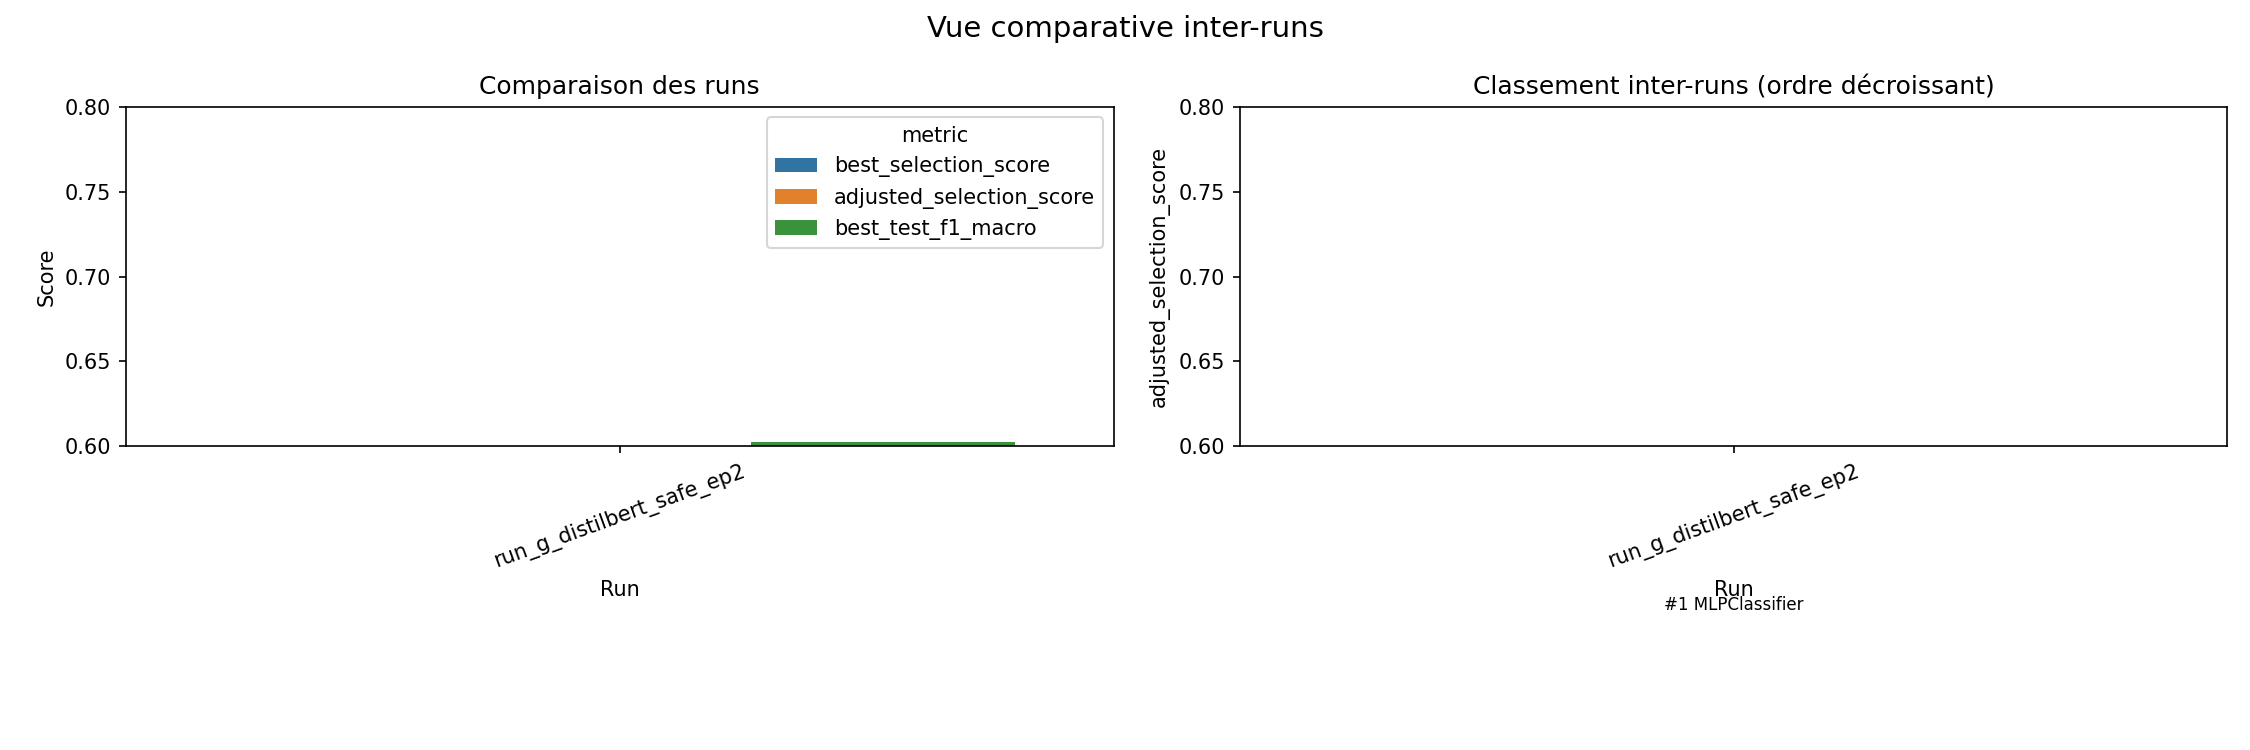

### models_compilation_overview.png

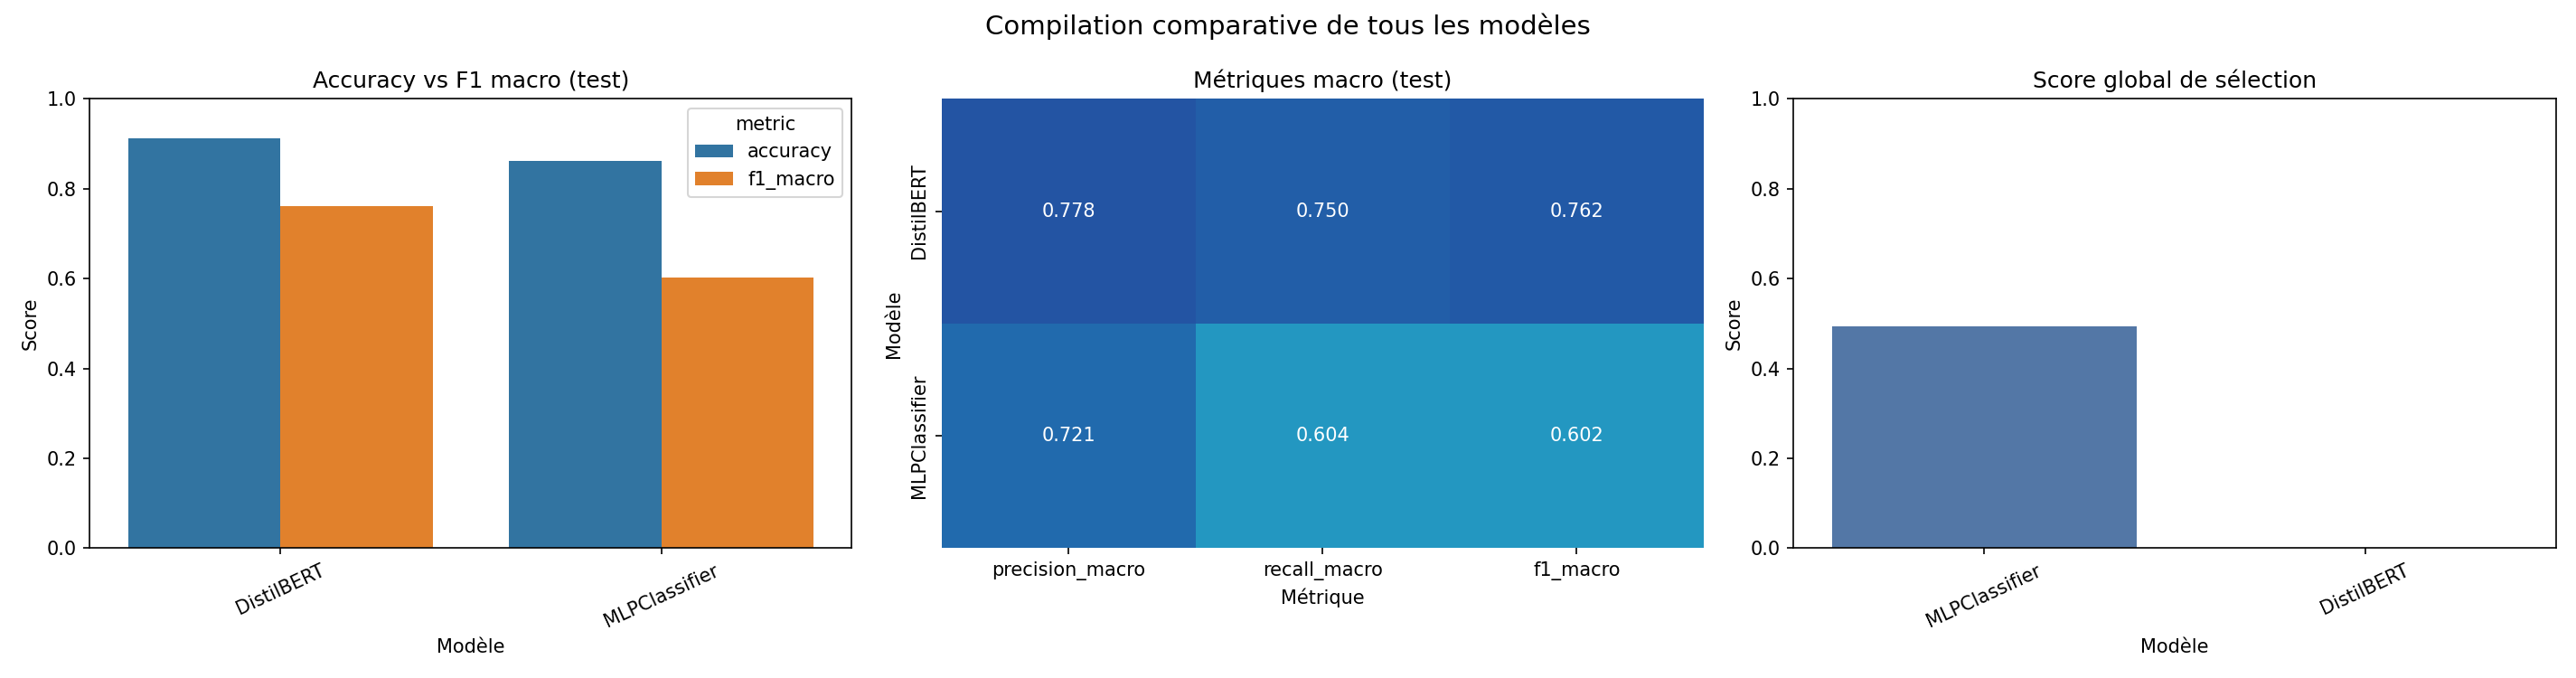

### models_status_overview.png

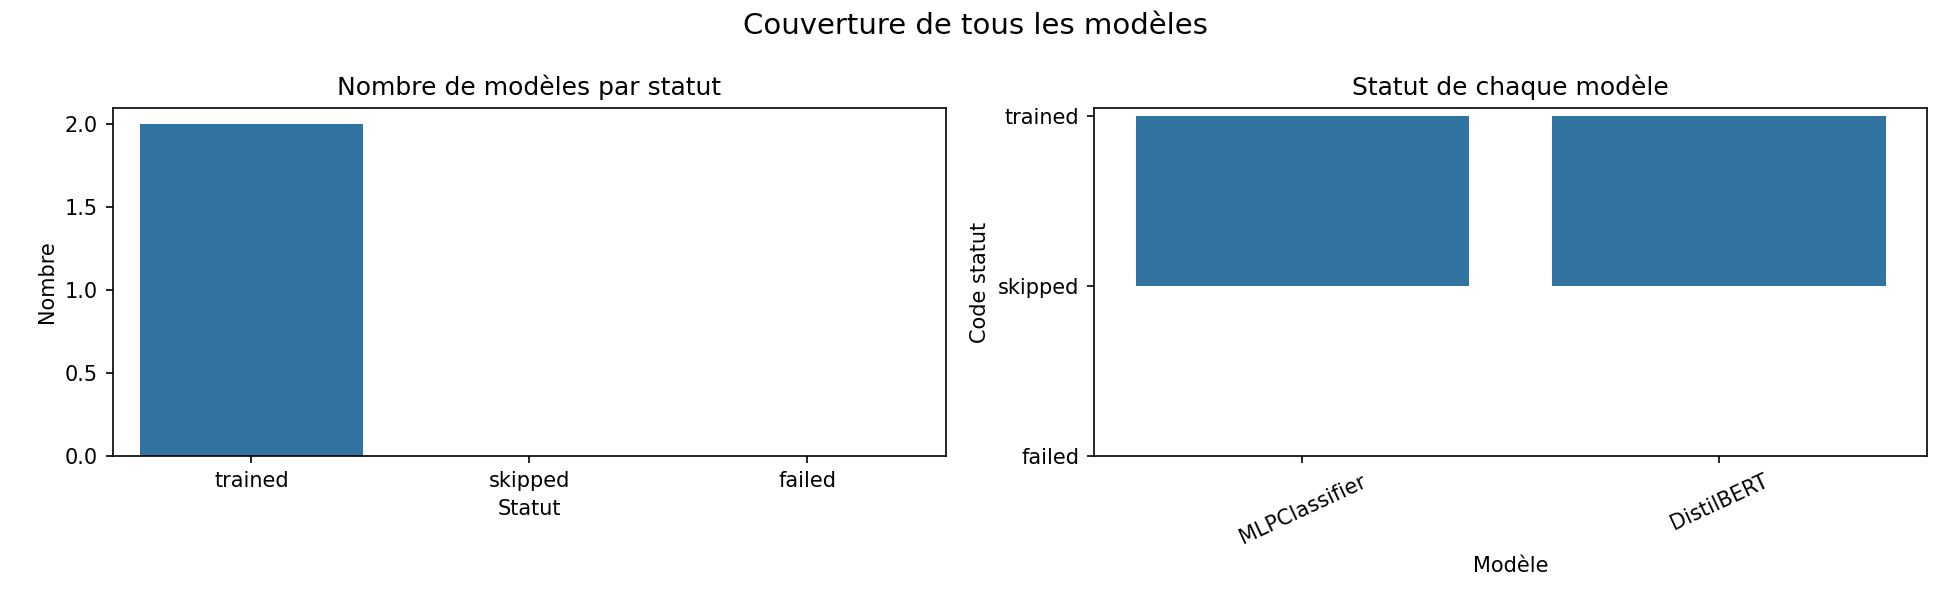

### confusion_matrices_all_models.png

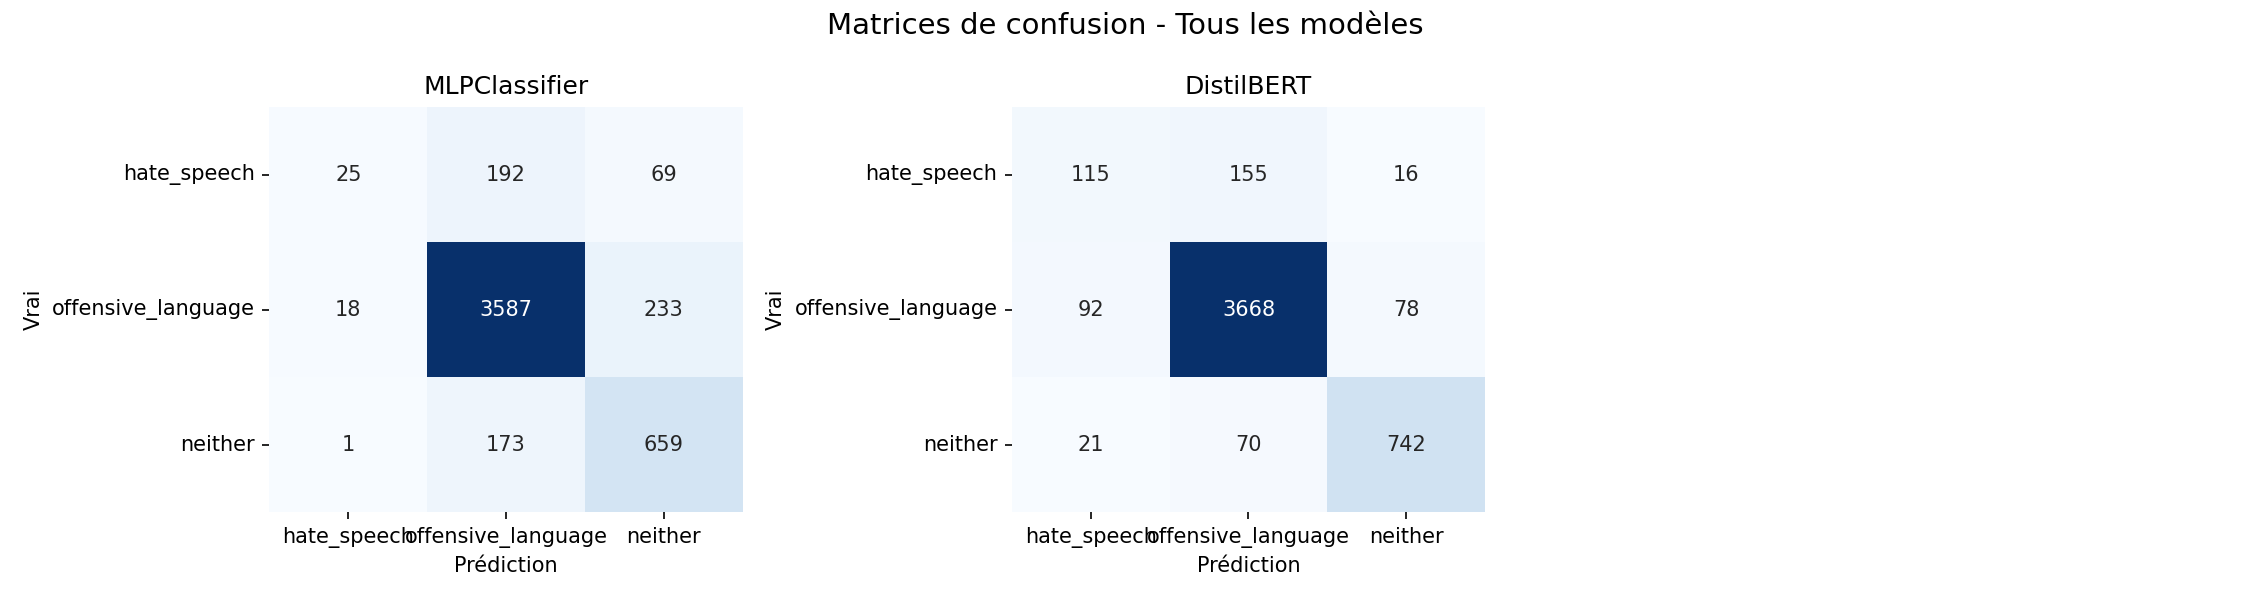

### models_comparison_test.png

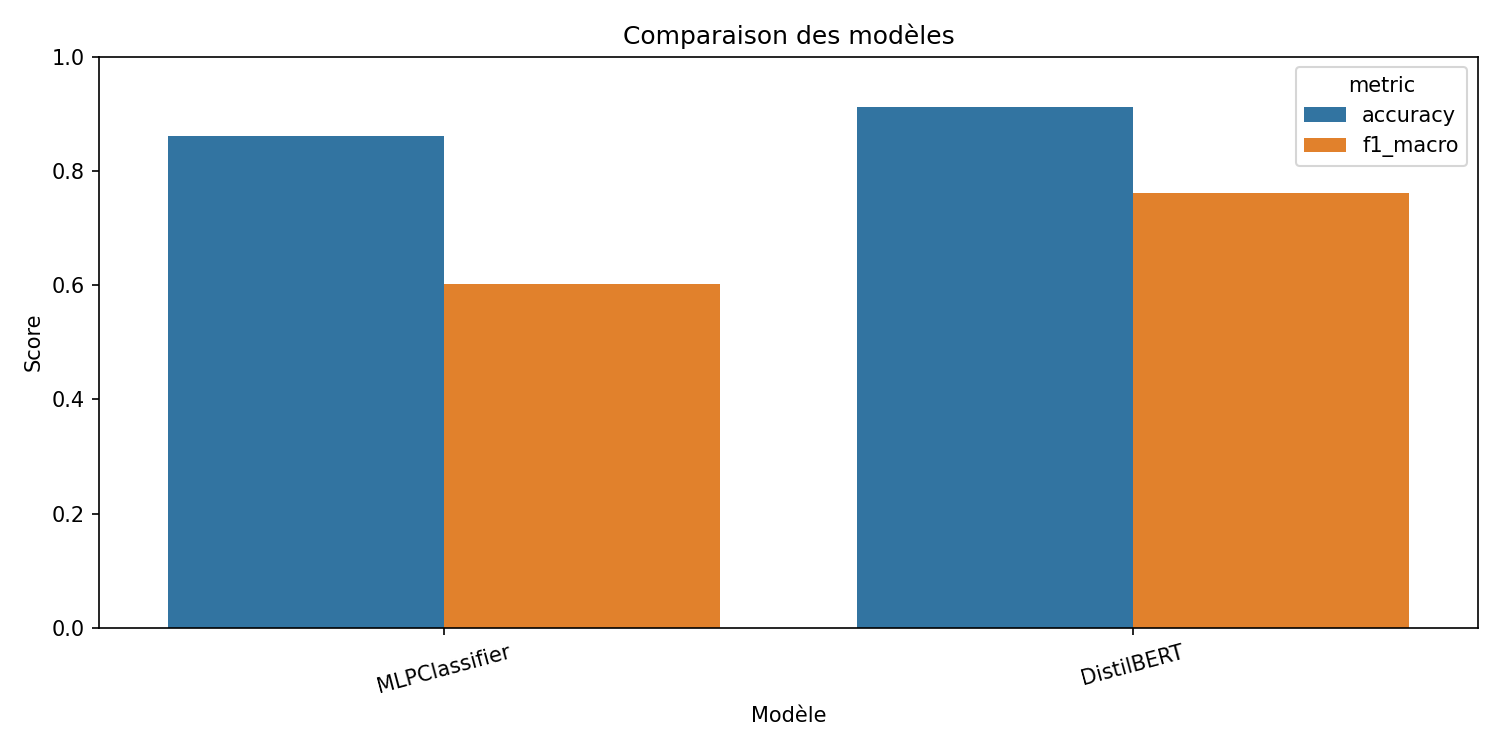

### learning_curve_best_model.png

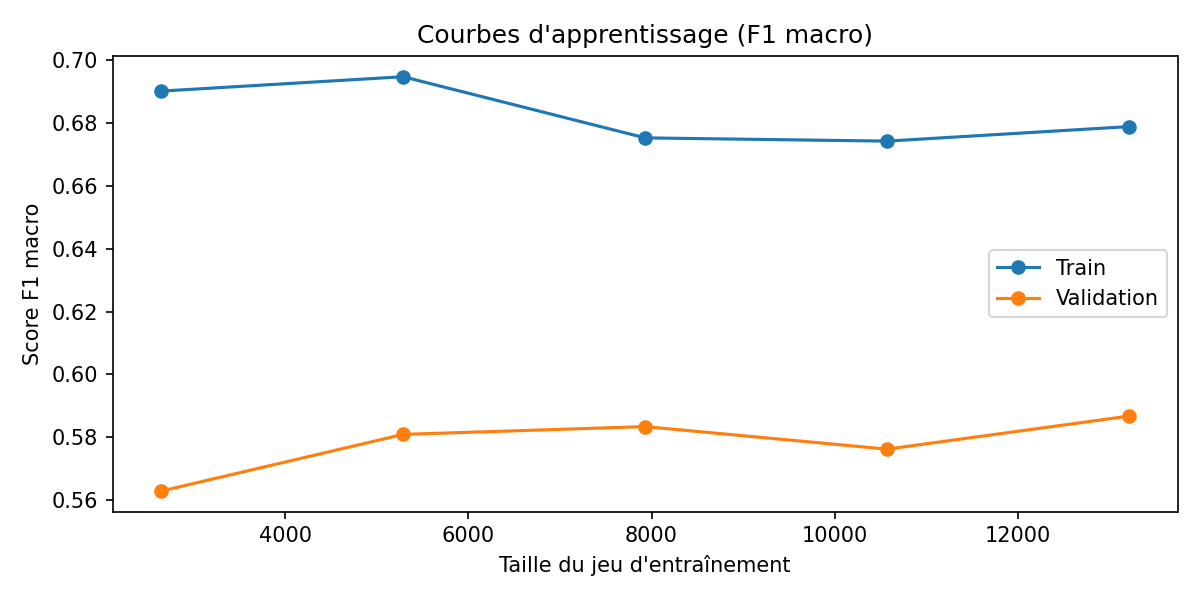

Figure absente: /workspace/Outputs/figures/feature_importance_best_model.png
Figure absente: /workspace/Outputs/figures/feature_importance_comparison_models.png


In [11]:
fig_dir = Path(artifacts["figures_dir"])
for fig_name in FIGURE_NAMES:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f"### {fig_name}"))
        display(Image(filename=str(fig_path)))
    else:
        print(f"Figure absente: {fig_path}")